[Cell 1] 라이브러리 임포트 및 결과 저장 경로 설정

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import talib

sns.set_style('whitegrid')
%matplotlib inline

# 그래프 내 한글이 깨지지 않도록 폰트 설정 (Windows 기본 내장 폰트 사용)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 결과물이 저장될 7단원 폴더 경로 (현재 작업 경로)
OUTPUT_DIR = Path('.')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"결과 저장 경로: {OUTPUT_DIR.resolve()}")

결과 저장 경로: G:\내 드라이브\03.졸업논문\ml4t_pipeline\model\7단원


[Cell 2] 원본 데이터 로드 (주가 + stocks 메타데이터 3개 컬럼: marketcap/ipoyear/sector — 책과 동일)

In [2]:
START = '2013-01-01'
END = '2017-12-31'
idx = pd.IndexSlice

# 키가 정상적으로 들어있는 HDF5 경로 지정
DATA_STORE = '../../data/data/assets.h5'

with pd.HDFStore(DATA_STORE) as store:
    prices = (
        store['quandl/wiki/prices']
        .loc[idx[START:END, :], ['adj_open', 'adj_close', 'adj_low', 'adj_high', 'adj_volume']]
        .rename(columns=lambda x: x.replace('adj_', ''))
        .swaplevel()
        .sort_index()
    )
    # 책(Machine Learning for Algorithmic Trading, 7단원)과 동일하게 3개 컬럼만 로드
    stocks = store['us_equities/stocks'].loc[:, ['marketcap', 'ipoyear', 'sector']]

print(f"Prices 데이터 수: {prices.shape[0]:,}건")
print(f"Stocks 데이터 수: {stocks.shape[0]:,}종목, {stocks.shape[1]}개 열")

Prices 데이터 수: 3,619,403건
Stocks 데이터 수: 7,152종목, 3개 열


[Cell 3] us_equities/stocks 변수 특성 확인 (EDA)

In [3]:
print("=" * 70)
print("1. us_equities/stocks 상위 5개 행 미리보기")
print("=" * 70)
display(stocks.head())

print("\n" + "=" * 70)
print("2. 변수별 결측치 비율 및 데이터 타입 요약")
print("=" * 70)
summary_df = pd.DataFrame({
    'Dtype': stocks.dtypes,
    '결측치_수': stocks.isnull().sum(),
    '결측치_비율(%)': (stocks.isnull().mean() * 100).round(2),
    '고윳값_수': stocks.nunique(),
    '구분': [
        '수치형 (연속형)' if np.issubdtype(dt, np.number) else '범주형/문자형'
        for dt in stocks.dtypes
    ]
})
display(summary_df)

# 수치형 변수 통계치
num_cols = stocks.select_dtypes(include=[np.number]).columns.tolist()
if num_cols:
    print("\n" + "=" * 70)
    print(f"3. 수치형 변수 통계치 및 범위 ({len(num_cols)}개)")
    print("=" * 70)
    display(stocks[num_cols].describe().T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']])

# 범주형/문자형 변수 빈도 및 형태 확인
cat_cols = stocks.select_dtypes(exclude=[np.number]).columns.tolist()
if cat_cols:
    print("\n" + "=" * 70)
    print(f"4. 범주형/문자형 변수 주요 고윳값 분포 ({len(cat_cols)}개)")
    print("=" * 70)
    for col in cat_cols:
        print(f"\n▶ 컬럼명: [{col}] (고윳값: {stocks[col].nunique()}개)")
        top_vals = stocks[col].value_counts(dropna=False).head(5)
        for val, count in top_vals.items():
            print(f"   - {repr(val)}: {count:,}건 ({count / len(stocks) * 100:.1f}%)")

1. us_equities/stocks 상위 5개 행 미리보기


,marketcap,ipoyear,sector
symbol,,,
AACG,NaN,2008.0,Real Estate
AACI,NaN,2026.0,Finance
AACIW,NaN,2026.0,Finance
AACO,NaN,2026.0,NaN
AACOU,NaN,2026.0,NaN



2. 변수별 결측치 비율 및 데이터 타입 요약


,Dtype,결측치_수,결측치_비율(%),고윳값_수,구분
marketcap,float64,7152,100.00,0,수치형 (연속형)
ipoyear,float64,3023,42.27,62,수치형 (연속형)
sector,object,719,10.05,12,범주형/문자형



3. 수치형 변수 통계치 및 범위 (2개)


,count,mean,std,min,25%,50%,75%,max
marketcap,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ipoyear,4129.0,2016.265197,10.943285,1925.0,2013.0,2020.0,2024.0,2026.0



4. 범주형/문자형 변수 주요 고윳값 분포 (1개)

▶ 컬럼명: [sector] (고윳값: 12개)
   - 'Finance': 1,692건 (23.7%)
   - 'Consumer Discretionary': 1,104건 (15.4%)
   - 'Health Care': 1,086건 (15.2%)
   - 'Technology': 786건 (11.0%)
   - nan: 719건 (10.1%)


[Cell 4] 유니버스 필터링 (최소 504거래일 + 상위 100위 롤링 거래대금)

In [4]:
# 1. 최소 2년(504 영업일) 이상 생존 종목 유지
min_obs = 504
nobs = prices.groupby(level='ticker').size()
keep_tickers = nobs[nobs >= min_obs].index
prices = prices.loc[idx[keep_tickers, :], :]

# 2. 거래대금(dollar_vol) 계산
prices['dollar_vol'] = prices['volume'] * prices['close']

# 3. 21일 롤링 평균 거래대금 계산
prices['dollar_vol_ma21'] = (
    prices.groupby(level='ticker')['dollar_vol']
    .transform(lambda x: x.rolling(window=21).mean())
)

# 4. 날짜별 단면 순위 산정 후 상위 100개 종목 추출
prices['dollar_vol_rank'] = (
    prices.groupby(level='date')['dollar_vol_ma21']
    .rank(ascending=False)
)
universe = prices[prices['dollar_vol_rank'] <= 100].copy()

print(f"필터링된 유니버스 레코드 수: {universe.shape[0]:,}건")
print(f"유니버스 종목 수: {universe.index.get_level_values('ticker').nunique()}개")

필터링된 유니버스 레코드 수: 123,828건
유니버스 종목 수: 348개


[Cell 5] 피처 엔지니어링 (책 7단원과 동일한 독립변수: 모멘텀 6종 + 시차 이동 모멘텀 20종 + 기술적 지표 5종(RSI·볼린저밴드·ATR·MACD) + 연도/월/섹터 더미)

In [5]:
# 1. 지연 수익률(모멘텀) 생성 — 책과 동일: 1/5/10/21/42/63일, 0.01~99.99분위 윈저라이즈 후
#    일간 기하평균 방식으로 변환 ((1+r)^(1/lag) - 1)
q = 0.0001
lags = [1, 5, 10, 21, 42, 63]
for lag in lags:
    universe[f'return_{lag}d'] = (
        universe.groupby(level='ticker')['close']
        .pct_change(lag)
        .pipe(lambda x: x.clip(lower=x.quantile(q), upper=x.quantile(1 - q)))
        .add(1)
        .pow(1 / lag)
        .sub(1)
    )

# 2. 시차 이동 모멘텀 — 이전 t기(1~5)의 수익률을 현재 시점 피처로 정렬 (책과 동일)
for t in [1, 2, 3, 4, 5]:
    for lag in [1, 5, 10, 21]:
        universe[f'return_{lag}d_lag{t}'] = (
            universe.groupby(level='ticker')[f'return_{lag}d'].shift(t * lag)
        )

# 3. 예측 타깃(forward returns): 1/5/10/21일 뒤 수익률
time_horizons = [1, 5, 10, 21]
for t in time_horizons:
    universe[f'target_{t}d'] = (
        universe.groupby(level='ticker')[f'return_{t}d'].shift(-t)
    )

# 4. 기술적 지표(TA-Lib) — RSI, 볼린저밴드, ATR, MACD (책과 동일)
universe['rsi'] = universe.groupby('ticker', group_keys=False).close.apply(talib.RSI)


def compute_bb(close):
    high, mid, low = talib.BBANDS(close)
    return pd.DataFrame({'bb_high': high, 'bb_low': low}, index=close.index)


universe = universe.join(universe.groupby('ticker', group_keys=False).close.apply(compute_bb))
universe['bb_high'] = universe.bb_high.sub(universe.close).div(universe.bb_high).apply(np.log1p)
universe['bb_low'] = universe.close.sub(universe.bb_low).div(universe.close).apply(np.log1p)


def compute_atr(stock_data):
    df = talib.ATR(stock_data.high, stock_data.low, stock_data.close, timeperiod=14)
    return df.sub(df.mean()).div(df.std())


universe['atr'] = universe.groupby('ticker', group_keys=False).apply(compute_atr)


def compute_macd(close):
    macd = talib.MACD(close)[0]
    return (macd - macd.mean()) / macd.std()


universe['macd'] = universe.groupby('ticker', group_keys=False).close.apply(compute_macd)

# 5. 달력(계절성) 더미 — year, month (책과 동일)
universe['year'] = universe.index.get_level_values('date').year
universe['month'] = universe.index.get_level_values('date').month

# 6. sector 결합 — 책과 동일하게 소문자/언더스코어로 정리하고, sector가 결측인 종목은 제외
stocks_sector = stocks[['sector']].dropna().copy()
stocks_sector['sector'] = stocks_sector['sector'].str.lower().str.replace(' ', '_')
shared_tickers = (
    universe.index.get_level_values('ticker').unique().intersection(stocks_sector.index)
)
data = universe.loc[idx[shared_tickers, :], :].join(stocks_sector, on='ticker', how='left')

# 7. year/month/sector를 한 번에 원-핫 인코딩 (책과 동일한 prefix 규칙)
cols_before_dummies = set(data.columns)
data = pd.get_dummies(
    data,
    columns=['year', 'month', 'sector'],
    prefix=['year', 'month', ''],
    prefix_sep=['_', '_', ''],
    drop_first=True,
    dtype=float,
)
dummy_features = [c for c in data.columns if c not in cols_before_dummies]

# 8. 독립변수 목록 취합
price_features = [f'return_{lag}d' for lag in lags] + [
    f'return_{lag}d_lag{t}' for t in [1, 2, 3, 4, 5] for lag in [1, 5, 10, 21]
]
ta_features = ['rsi', 'bb_high', 'bb_low', 'atr', 'macd']
all_features = price_features + ta_features + dummy_features
target_cols = [f'target_{t}d' for t in time_horizons]

# 9. 수치형 피처 내 잔여 결측치 0 대치 (행 삭제 금지)
data[all_features] = data[all_features].fillna(0.0)

# 오직 예측 타깃 및 핵심 모멘텀 팩터에 대해서만 dropna 적용
data = data.dropna(subset=['target_1d', 'return_1d']).copy()

print("=" * 60)
print(f"최종 정제 데이터 수: {len(data):,}건 (정상 복원 확인)")
print(f"총 독립변수 개수: {len(all_features)}개 "
      f"(모멘텀 {len(price_features)} + 기술지표 {len(ta_features)} + 연도/월/섹터 더미 {len(dummy_features)})")
print("=" * 60)
print("\n[생성된 독립변수 전체 목록]:")
print(all_features)

print("\n[전처리 완료된 데이터 상위 3건 미리보기]:")
display(data[all_features + ['target_1d']].head(3))

최종 정제 데이터 수: 102,334건 (정상 복원 확인)
총 독립변수 개수: 56개 (모멘텀 26 + 기술지표 5 + 연도/월/섹터 더미 25)

[생성된 독립변수 전체 목록]:
['return_1d', 'return_5d', 'return_10d', 'return_21d', 'return_42d', 'return_63d', 'return_1d_lag1', 'return_5d_lag1', 'return_10d_lag1', 'return_21d_lag1', 'return_1d_lag2', 'return_5d_lag2', 'return_10d_lag2', 'return_21d_lag2', 'return_1d_lag3', 'return_5d_lag3', 'return_10d_lag3', 'return_21d_lag3', 'return_1d_lag4', 'return_5d_lag4', 'return_10d_lag4', 'return_21d_lag4', 'return_1d_lag5', 'return_5d_lag5', 'return_10d_lag5', 'return_21d_lag5', 'rsi', 'bb_high', 'bb_low', 'atr', 'macd', 'year_2014', 'year_2015', 'year_2016', 'year_2017', 'month_2', 'month_3', 'month_4', 'month_5', 'month_6', 'month_7', 'month_8', 'month_9', 'month_10', 'month_11', 'month_12', 'consumer_discretionary', 'consumer_staples', 'energy', 'finance', 'health_care', 'industrials', 'real_estate', 'technology', 'telecommunications', 'utilities']

[전처리 완료된 데이터 상위 3건 미리보기]:


return_1d  return_5d  return_10d  return_21d  return_42d  \
ticker date                                                                   
AAL    2013-01-31   0.000000        0.0         0.0         0.0         0.0   
       2013-02-01  -0.011204        0.0         0.0         0.0         0.0   
       2013-02-04  -0.009207        0.0         0.0         0.0         0.0   

                   return_63d  return_1d_lag1  return_5d_lag1  \
ticker date                                                     
AAL    2013-01-31         0.0        0.000000             0.0   
       2013-02-01         0.0        0.000000             0.0   
       2013-02-04         0.0       -0.011204             0.0   

                   return_10d_lag1  return_21d_lag1  ...  consumer_staples  \
ticker date                                          ...                     
AAL    2013-01-31              0.0              0.0  ...               0.0   
       2013-02-01              0.0              0.0  ...               0.0   
       2013-02-04              0.0              0.0  ...               0.0   

                   energy  finance  health_care  industrials  real_estate  \
ticker date                                                                 
AAL    2013-01-31     0.0      0.0          0.0          0.0          0.0   
       2013-02-01     0.0      0.0          0.0          0.0          0.0   
       2013-02-04     0.0      0.0          0.0          0.0          0.0   

                   technology  telecommunications  utilities  target_1d  
ticker date                                                              
AAL    2013-01-31         0.0                 0.0        0.0  -0.011204  
       2013-02-01         0.0                 0.0        0.0  -0.009207  
       2013-02-04         0.0                 0.0        0.0   0.007148  

[3 rows x 57 columns]

[Cell 6] 롤링 윈도우 Walk-Forward 백테스트 및 CSV 결과 파일 저장

In [6]:
import joblib

YEAR = 252
train_period_length = 63   # 3개월 학습
test_period_length = 10    # 2주 검증
n_splits = int(3 * YEAR / test_period_length)
HORIZONS = [1, 5, 10, 21]  # 1일/5일/10일/21일 뒤 수익률 예측 모델을 각각 학습

dates = data.index.get_level_values('date').unique().sort_values()
total_dates = len(dates)

metrics_by_horizon = {}       # 호라이즌별 일별 IC/RMSE
preds_by_horizon = {}         # 호라이즌별 워크포워드 OOS 예측치
coef_by_horizon = {}          # 호라이즌별 윈도우별 회귀계수
final_model_by_horizon = {}   # 호라이즌별 "가장 최근" 윈도우에서 학습된 최종 모델
last_split_info_by_horizon = {}  # 위 최종 모델 학습에 사용된 데이터(결정 경계/summary 시각화용)

for lookahead in HORIZONS:
    target_col = f'target_{lookahead}d'
    daily_metrics = []
    predictions_list = []
    coef_list = []
    captured_final = False  # 가장 최근(i가 가장 작은) 유효 윈도우를 한 번만 "최종 모델"로 저장하기 위한 플래그

    print(f"\n[{lookahead}일 뒤 예측] 총 {n_splits}회 롤링 윈도우 Walk-Forward 검증 수행 중...")

    for i in range(n_splits):
        test_end_idx = total_dates - i * test_period_length
        test_start_idx = test_end_idx - test_period_length
        train_end_idx = test_start_idx
        train_start_idx = train_end_idx - train_period_length

        if train_start_idx < 0:
            break

        train_dates = dates[train_start_idx:train_end_idx]
        test_dates = dates[test_start_idx:test_end_idx]

        train_mask = data.index.get_level_values('date').isin(train_dates)
        test_mask = data.index.get_level_values('date').isin(test_dates)

        # 호라이즌이 길어질수록(target_5d/10d/21d) 데이터 마지막 구간에 결측(NaN)이 생기므로
        # 해당 타깃 기준으로 결측 행을 제외하고 학습/평가 (행 삭제는 이 호라이즌 학습에만 국한됨)
        train_data = data[train_mask].dropna(subset=[target_col])
        test_data = data[test_mask].dropna(subset=[target_col])

        if len(train_data) == 0 or len(test_data) == 0:
            continue

        # 분산이 0인 상수 열 제외
        valid_features = [col for col in all_features if train_data[col].std() > 1e-8]
        if len(valid_features) == 0:
            valid_features = price_features

        X_train = train_data[valid_features].astype(float)
        y_train = train_data[target_col].astype(float)
        X_test = test_data[valid_features].astype(float)
        y_test = test_data[target_col].astype(float)

        # 정규화
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0)
        X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0)

        # 릿지 모델 학습
        model = Ridge(alpha=10.0, random_state=42)
        model.fit(X_train_scaled, y_train)

        # 회귀 계수(Feature Importance) 기록
        coef_series = pd.Series(model.coef_, index=valid_features)
        coef_series['intercept'] = model.intercept_
        coef_series['split_date'] = test_dates[0]
        coef_list.append(coef_series)

        # 가장 최근(=가장 작은 i) 유효 윈도우의 모델을 "최종 모델"로 1회만 저장
        # (반복문이 끝까지 돌면 마지막에 남는 변수는 가장 오래된 윈도우이므로, 루프 종료 후 저장하면 안 됨)
        if not captured_final:
            final_model_by_horizon[lookahead] = {
                'model': model, 'scaler': scaler, 'features': valid_features, 'alpha': model.alpha
            }
            last_split_info_by_horizon[lookahead] = {
                'train_data': train_data.copy(), 'test_data': test_data.copy(),
                'valid_features': valid_features,
                'X_train_scaled': X_train_scaled, 'X_test_scaled': X_test_scaled,
                'y_train': y_train.copy(), 'y_test': y_test.copy(),
                'scaler': scaler, 'model': model, 'target_col': target_col,
            }
            captured_final = True

        test_eval = test_data[[target_col]].copy()
        test_eval['predicted_ret'] = model.predict(X_test_scaled)
        test_eval['test_date'] = test_eval.index.get_level_values('date')
        predictions_list.append(test_eval[['predicted_ret', target_col]])

        # 일별 단면 IC 및 RMSE 계산
        for dt, group in test_eval.groupby('test_date'):
            y_true = group[target_col]
            y_pred = group['predicted_ret']

            if len(group) >= 5 and y_true.std() > 1e-8 and y_pred.std() > 1e-8:
                ic, _ = spearmanr(y_true, y_pred)
                rmse = np.sqrt(mean_squared_error(y_true, y_pred))
                if not np.isnan(ic):
                    daily_metrics.append({'date': dt, 'ic': ic, 'rmse': rmse})

    metrics_df_h = pd.DataFrame(daily_metrics).dropna().set_index('date').sort_index()
    all_preds_df_h = pd.concat(predictions_list).sort_index()
    coef_df_h = pd.DataFrame(coef_list).set_index('split_date').fillna(0.0)

    metrics_by_horizon[lookahead] = metrics_df_h
    preds_by_horizon[lookahead] = all_preds_df_h
    coef_by_horizon[lookahead] = coef_df_h

    # 호라이즌별 CSV 저장
    metrics_df_h.to_csv(OUTPUT_DIR / f'rolling_metrics_result_{lookahead}d.csv')
    all_preds_df_h.to_csv(OUTPUT_DIR / f'predictions_result_{lookahead}d.csv')
    coef_df_h.to_csv(OUTPUT_DIR / f'model_coefficients_{lookahead}d.csv')

    mean_ic = metrics_df_h['ic'].mean()
    std_ic = metrics_df_h['ic'].std()
    icir = mean_ic / std_ic if std_ic != 0 else 0
    mean_rmse = metrics_df_h['rmse'].mean()
    print(f"  평가일수={len(metrics_df_h):,}일 | MeanIC={mean_ic:.4f} | ICIR={icir:.4f} | MeanRMSE={mean_rmse:.4f}")

# 모든 호라이즌의 최종 모델을 하나의 joblib 파일로 저장
model_joblib_path = OUTPUT_DIR / 'final_ridge_models_all_horizons.joblib'
joblib.dump(final_model_by_horizon, model_joblib_path)

# ---- 이후 셀(Cell 7)과의 하위 호환을 위해 1일 호라이즌 결과를 기본 변수명으로도 유지 ----
lookahead = 1
target_col = 'target_1d'
metrics_df = metrics_by_horizon[1]
all_preds_df = preds_by_horizon[1]
coef_df = coef_by_horizon[1]
model_artifacts = final_model_by_horizon[1]

# 기존 방식과 동일한 이름으로도 1일 호라이즌 결과를 저장 (하위 호환)
metrics_df.to_csv(OUTPUT_DIR / 'rolling_metrics_result.csv')
all_preds_df.to_csv(OUTPUT_DIR / 'predictions_result.csv')
coef_df.to_csv(OUTPUT_DIR / 'model_coefficients.csv')
joblib.dump(model_artifacts, OUTPUT_DIR / 'final_ridge_model.joblib')

print("\n" + "=" * 60)
print("--- [전체 호라이즌 학습 완료 요약] ---")
for h in HORIZONS:
    m = metrics_by_horizon[h]
    print(f"  {h:>2}일 호라이즌: 평가일수={len(m):,}일, MeanIC={m['ic'].mean():.4f}, "
          f"ICIR={(m['ic'].mean() / m['ic'].std() if m['ic'].std() != 0 else 0):.4f}")
print("=" * 60)
print(f"★ 전체 호라이즌 모델 저장 완료 (.joblib): {model_joblib_path.resolve()}")


[1일 뒤 예측] 총 75회 롤링 윈도우 Walk-Forward 검증 수행 중...
  평가일수=749일 | MeanIC=0.0062 | ICIR=0.0374 | MeanRMSE=0.0195

[5일 뒤 예측] 총 75회 롤링 윈도우 Walk-Forward 검증 수행 중...
  평가일수=745일 | MeanIC=0.0260 | ICIR=0.1532 | MeanRMSE=0.0093

[10일 뒤 예측] 총 75회 롤링 윈도우 Walk-Forward 검증 수행 중...
  평가일수=740일 | MeanIC=0.0598 | ICIR=0.3530 | MeanRMSE=0.0064

[21일 뒤 예측] 총 75회 롤링 윈도우 Walk-Forward 검증 수행 중...
  평가일수=729일 | MeanIC=0.1383 | ICIR=0.8022 | MeanRMSE=0.0041

--- [전체 호라이즌 학습 완료 요약] ---
   1일 호라이즌: 평가일수=749일, MeanIC=0.0062, ICIR=0.0374
   5일 호라이즌: 평가일수=745일, MeanIC=0.0260, ICIR=0.1532
  10일 호라이즌: 평가일수=740일, MeanIC=0.0598, ICIR=0.3530
  21일 호라이즌: 평가일수=729일, MeanIC=0.1383, ICIR=0.8022
★ 전체 호라이즌 모델 저장 완료 (.joblib): G:\내 드라이브\03.졸업논문\ml4t_pipeline\model\7단원\final_ridge_models_all_horizons.joblib


[Cell 7] 결과 시각화 및 이미지 파일 저장

그래프 이미지 저장 위치: G:\내 드라이브\03.졸업논문\ml4t_pipeline\model\7단원\rolling_performance_plot.png


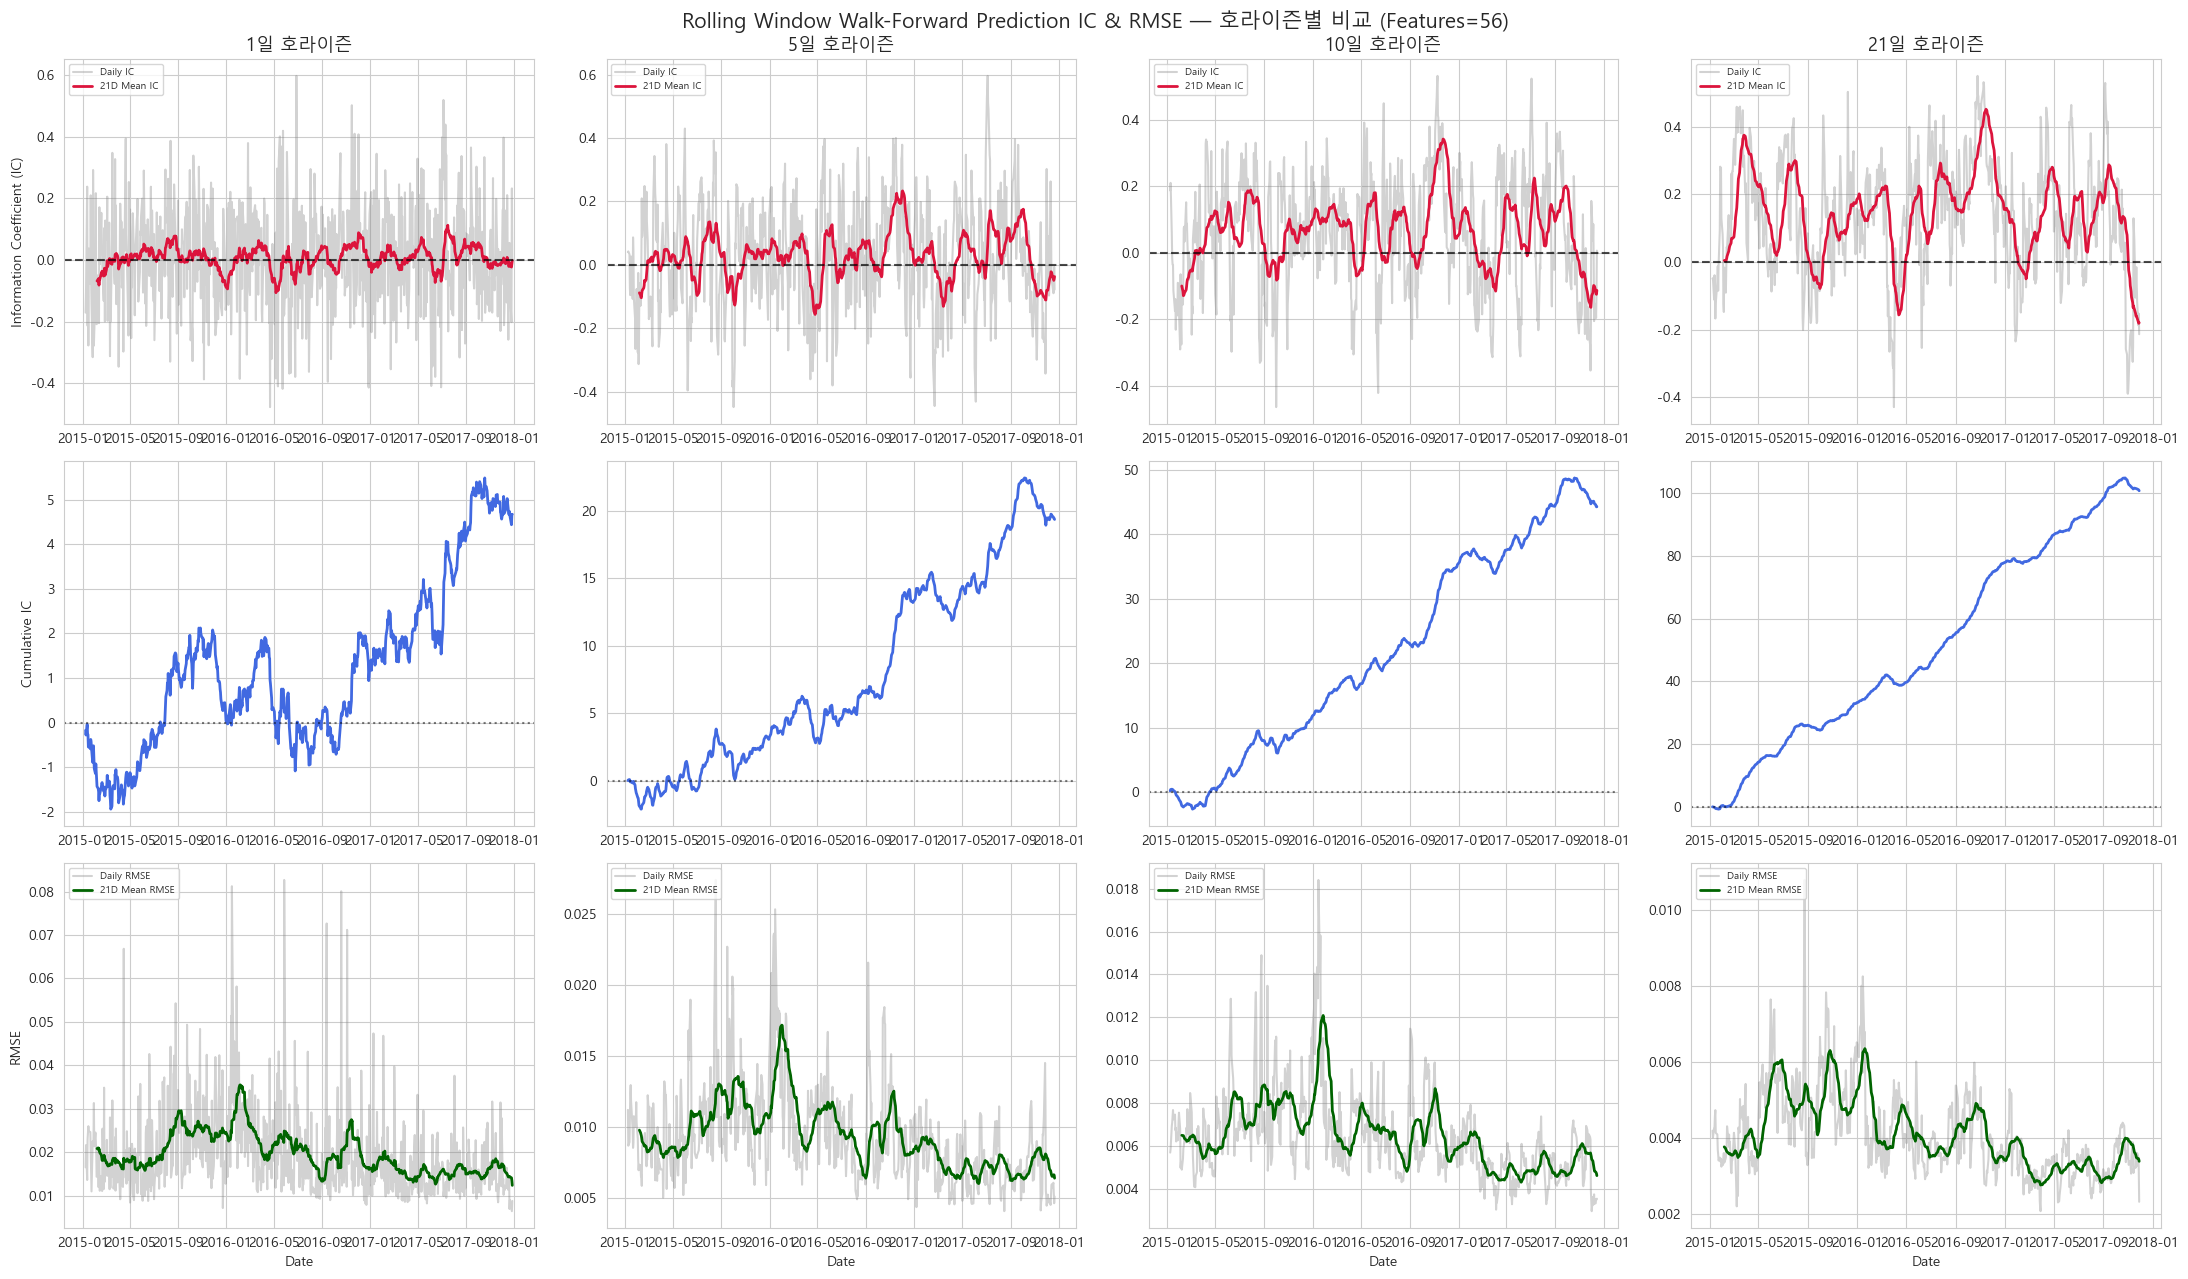

In [7]:
fig, axes = plt.subplots(3, 4, figsize=(22, 13), sharex=False)

for col, h in enumerate(HORIZONS):
    m = metrics_by_horizon[h]

    # 1행: Daily IC + 21일 롤링 평균
    axes[0, col].plot(m.index, m['ic'], color='gray', alpha=0.35, label='Daily IC')
    axes[0, col].plot(m.index, m['ic'].rolling(21).mean(), color='crimson', lw=2, label='21D Mean IC')
    axes[0, col].axhline(0, color='black', linestyle='--', alpha=0.7)
    axes[0, col].set_title(f'{h}일 호라이즌', fontsize=13)
    if col == 0:
        axes[0, col].set_ylabel('Information Coefficient (IC)')
    axes[0, col].legend(loc='upper left', fontsize=7)

    # 2행: Cumulative IC
    axes[1, col].plot(m.index, m['ic'].cumsum(), color='royalblue', lw=2)
    axes[1, col].axhline(0, color='black', linestyle=':', alpha=0.5)
    if col == 0:
        axes[1, col].set_ylabel('Cumulative IC')

    # 3행: Daily RMSE + 21일 롤링 평균
    axes[2, col].plot(m.index, m['rmse'], color='gray', alpha=0.35, label='Daily RMSE')
    axes[2, col].plot(m.index, m['rmse'].rolling(21).mean(), color='darkgreen', lw=2, label='21D Mean RMSE')
    if col == 0:
        axes[2, col].set_ylabel('RMSE')
    axes[2, col].set_xlabel('Date')
    axes[2, col].legend(loc='upper left', fontsize=7)

plt.suptitle(f'Rolling Window Walk-Forward Prediction IC & RMSE — 호라이즌별 비교 (Features={len(all_features)})',
             fontsize=15)
plt.tight_layout()

# 이미지 파일 저장 (7단원 폴더 내)
plot_png_path = OUTPUT_DIR / 'rolling_performance_plot.png'
fig.savefig(plot_png_path, dpi=200)
print(f"그래프 이미지 저장 위치: {plot_png_path.resolve()}")

plt.show()

[Cell 8] Backtrader 백테스트 — 예측 호라이즌별(1/5/10/21일) 롱숏(Long-Short) 팩터 전략

Cell 6에서 학습한 4개 호라이즌(1일/5일/10일/21일) 릿지 모델의 워크포워드 OOS 예측치(`preds_by_horizon`)를 각각 매매 신호로 사용합니다.
호라이즌 `h`일 예측 모델은 **`h`거래일마다 리밸런싱**하며(예측이 유효한 기간만큼 포지션을 보유), 매 리밸런싱 시점에 예측 수익률 상위 `N_SELECT`개 종목은 매수(Long), 하위 `N_SELECT`개 종목은 매도(Short)하여 동일가중으로 배분하는 시장 중립(Market-Neutral) 전략을 **Backtrader** 엔진으로 백테스트합니다.

- 사전 설치: `pip install backtrader exchange_calendars`
- 매매 비용: **거래(체결) 1회당 고정 $0.02** (거래 금액과 무관한 정액 수수료)
- 거래일 캘린더: Cell 9의 Zipline과 동일하게 실제 NYSE 거래일 캘린더(`exchange_calendars`)를 사용
- 결과물: 4개 호라이즌의 누적 수익률 곡선을 **하나의 그림 안에 2x2 서브플롯**으로 출력

In [8]:
# pip install backtrader exchange_calendars (최초 1회 실행 필요)
import backtrader as bt
import exchange_calendars as xcals

N_SELECT = 10                     # 롱/숏 각각 선택할 종목 수
INITIAL_CASH = 1_000_000
COMMISSION_PER_TRADE = 0.02       # 거래(체결) 1회당 고정 수수료($)
_cal = xcals.get_calendar('XNYS')


# Backtrader용 커스텀 데이터 피드 (예측치를 추가 라인으로 포함)
class MLSignalData(bt.feeds.PandasData):
    lines = ('predicted',)
    params = (('predicted', -1),)


# 거래 금액과 무관하게 체결 1회당 고정 $0.02를 부과하는 수수료 모델
class FlatTradeCommission(bt.CommInfoBase):
    params = (('commission', COMMISSION_PER_TRADE), ('stocklike', True))

    def _getcommission(self, size, price, pseudoexec):
        return self.p.commission if size != 0 else 0.0


# 전략: 예측 수익률 상위 N개 매수 / 하위 N개 매도, 동일가중, h거래일마다 리밸런싱
class MLLongShortStrategy(bt.Strategy):
    params = dict(n_select=N_SELECT, rebalance_every=1)

    def __init__(self):
        self.bar_count = 0

    def next(self):
        self.bar_count += 1
        if (self.bar_count - 1) % self.p.rebalance_every != 0:
            return  # 보유 기간 동안은 리밸런싱하지 않고 기존 포지션 유지

        signals = {d._name: d.predicted[0] for d in self.datas if not np.isnan(d.predicted[0])}
        if len(signals) < 2 * self.p.n_select:
            for d in self.datas:
                if self.getposition(d).size != 0:
                    self.order_target_percent(d, target=0.0)
            return

        ranked = sorted(signals.items(), key=lambda kv: kv[1], reverse=True)
        weight = 1.0 / self.p.n_select
        targets = {name: weight for name, _ in ranked[:self.p.n_select]}
        targets.update({name: -weight for name, _ in ranked[-self.p.n_select:]})

        by_name = {d._name: d for d in self.datas}
        for name, d in by_name.items():
            tgt = targets.get(name, 0.0)
            if tgt != 0.0 or self.getposition(d).size != 0:
                self.order_target_percent(d, target=tgt)


def run_backtrader_for_horizon(h, pred_df):
    """호라이즌 h에 대해 Backtrader 백테스트를 1회 실행하고 결과를 dict로 반환"""
    pred_series_h = pred_df['predicted_ret']
    tickers_h = pred_series_h.index.get_level_values('ticker').unique().tolist()
    _start = pred_series_h.index.get_level_values('date').min()
    _end = pred_series_h.index.get_level_values('date').max()
    sessions_h = _cal.sessions_in_range(_start, _end)
    sessions_h = pd.DatetimeIndex(sessions_h.tz_localize(None) if sessions_h.tz is not None else sessions_h)

    cerebro = bt.Cerebro()
    cerebro.broker.setcash(INITIAL_CASH)
    cerebro.broker.addcommissioninfo(FlatTradeCommission())

    n_feeds = 0
    for t in tickers_h:
        try:
            dft = prices.loc[t, ['open', 'high', 'low', 'close', 'volume']].copy()
        except KeyError:
            continue
        if dft.empty:
            continue
        dft = dft.reindex(sessions_h)
        dft[['open', 'high', 'low', 'close']] = dft[['open', 'high', 'low', 'close']].ffill().bfill()
        dft['volume'] = dft['volume'].fillna(0)
        dft['predicted'] = pred_series_h.xs(t, level='ticker').reindex(sessions_h)
        if dft['predicted'].notna().sum() == 0:
            continue
        cerebro.adddata(MLSignalData(dataname=dft), name=t)
        n_feeds += 1

    cerebro.addstrategy(MLLongShortStrategy, rebalance_every=h)
    cerebro.addanalyzer(bt.analyzers.TimeReturn, _name='time_return')
    cerebro.addanalyzer(bt.analyzers.SharpeRatio, _name='sharpe', timeframe=bt.TimeFrame.Days, annualize=True, riskfreerate=0.0)
    cerebro.addanalyzer(bt.analyzers.DrawDown, _name='drawdown')

    start_value = cerebro.broker.getvalue()
    results = cerebro.run()
    end_value = cerebro.broker.getvalue()
    strat = results[0]

    returns = pd.Series(strat.analyzers.time_return.get_analysis()).sort_index()
    returns.index = pd.to_datetime(returns.index)
    sharpe = strat.analyzers.sharpe.get_analysis().get('sharperatio')
    maxdd = strat.analyzers.drawdown.get_analysis().max.drawdown

    return {'sessions': sessions_h, 'n_feeds': n_feeds, 'returns': returns,
            'start_value': start_value, 'end_value': end_value, 'sharpe': sharpe, 'maxdd': maxdd}


bt_results_by_horizon = {}
for h in HORIZONS:
    print(f"\n[Backtrader] {h}일 호라이즌 백테스트 실행 중 (리밸런싱 주기 {h}거래일)...")
    res = run_backtrader_for_horizon(h, preds_by_horizon[h])
    bt_results_by_horizon[h] = res
    sh = res['sharpe']
    print(f"  종목 피드 {res['n_feeds']}개 | 최종자산 {res['end_value']:,.0f} | "
          + (f"Sharpe {sh:.4f}" if sh is not None else "Sharpe N/A") + f" | MDD {res['maxdd']:.2f}%")


[Backtrader] 1일 호라이즌 백테스트 실행 중 (리밸런싱 주기 1거래일)...
  종목 피드 200개 | 최종자산 887,699 | Sharpe -0.2020 | MDD 17.53%

[Backtrader] 5일 호라이즌 백테스트 실행 중 (리밸런싱 주기 5거래일)...
  종목 피드 188개 | 최종자산 1,608,222 | Sharpe 1.1579 | MDD 12.88%

[Backtrader] 10일 호라이즌 백테스트 실행 중 (리밸런싱 주기 10거래일)...
  종목 피드 183개 | 최종자산 3,918,477 | Sharpe 3.2265 | MDD 8.02%

[Backtrader] 21일 호라이즌 백테스트 실행 중 (리밸런싱 주기 21거래일)...
  종목 피드 159개 | 최종자산 2,178,466 | Sharpe 1.6989 | MDD 12.25%


Backtrader 호라이즌별 결과 그래프 저장 위치: G:\내 드라이브\03.졸업논문\ml4t_pipeline\model\7단원\backtrader_multi_horizon_plot.png


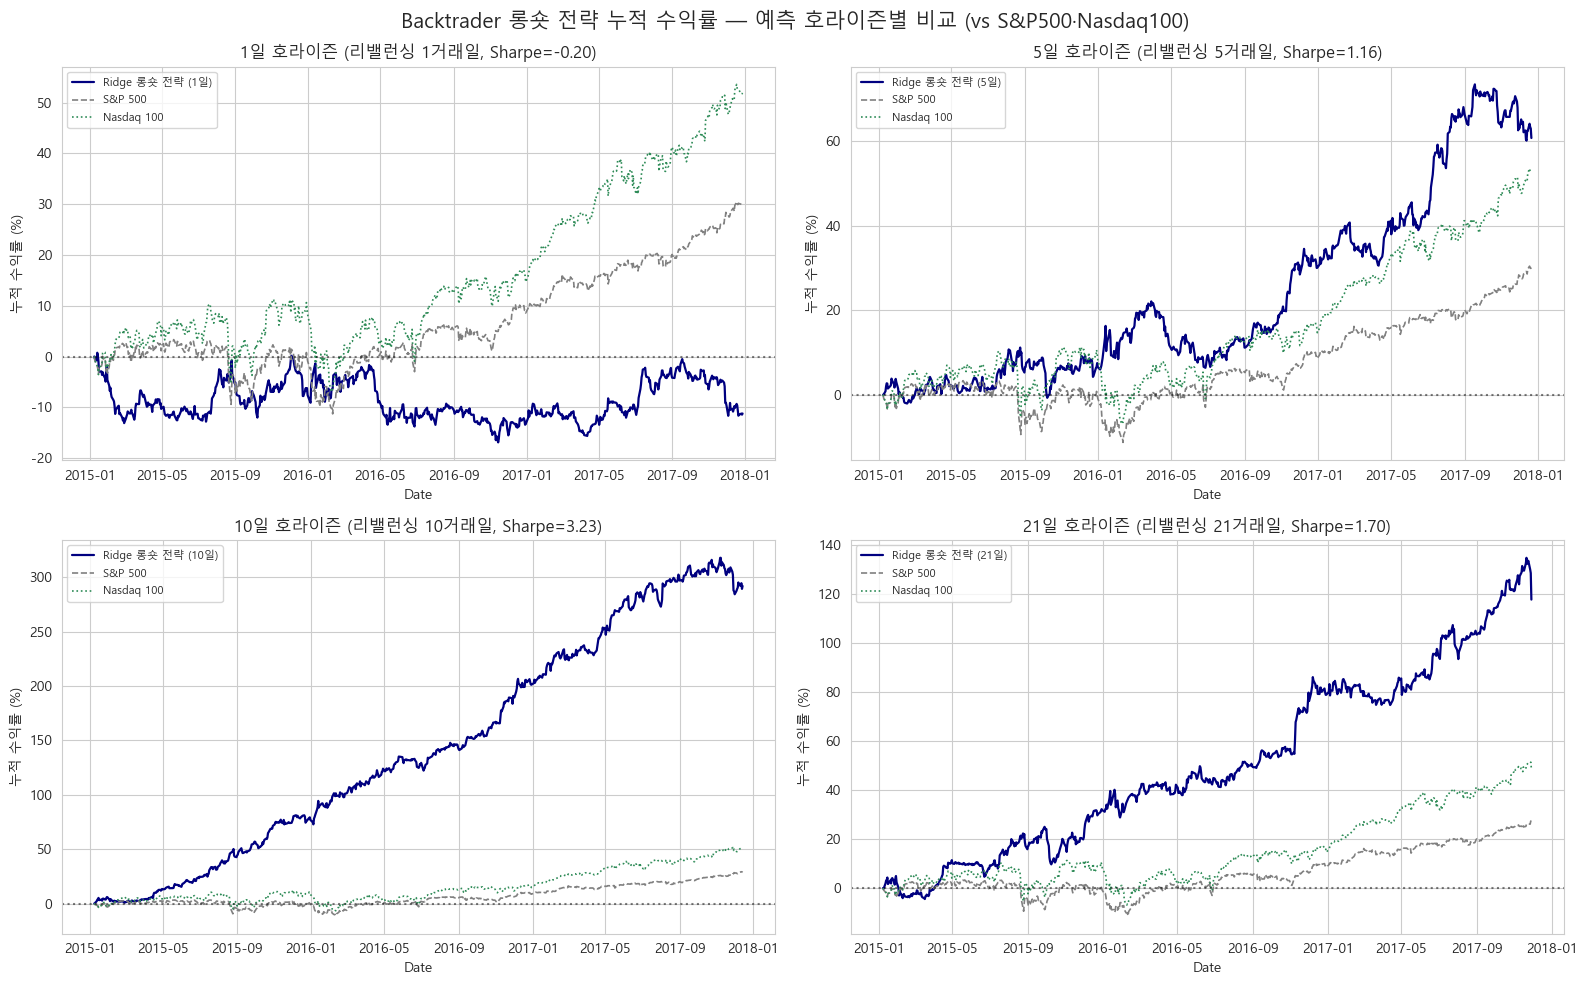

In [9]:
# 벤치마크 다운로드: S&P500(^GSPC), 나스닥100(^NDX) — 백테스트 실제 기간에 맞춰 리베이스
import yfinance as yf

_bt_start = min(bt_results_by_horizon[h]['returns'].index.min() for h in HORIZONS)
_bt_end = max(bt_results_by_horizon[h]['returns'].index.max() for h in HORIZONS)


def _download_benchmark(ticker, start, end):
    raw = yf.download(ticker, start=str(start.date()),
                       end=str((end + pd.Timedelta(days=5)).date()), progress=False)
    close = raw['Close']
    if isinstance(close, pd.DataFrame):
        close = close.iloc[:, 0]
    close.index = pd.to_datetime(close.index).tz_localize(None)
    return close


_sp500_close = _download_benchmark('^GSPC', _bt_start, _bt_end)
_ndx_close = _download_benchmark('^NDX', _bt_start, _bt_end)
_cal_dates = pd.date_range(_bt_start, _bt_end, freq='D')
_sp500_full = _sp500_close.reindex(_cal_dates).ffill().bfill()
_ndx_full = _ndx_close.reindex(_cal_dates).ffill().bfill()


def _benchmark_cum_pct(series_full, target_index):
    """target_index의 첫 날짜를 0%로 리베이스한 누적 수익률(%)"""
    aligned = series_full.reindex(target_index).ffill().bfill()
    return (aligned / aligned.iloc[0] - 1) * 100


# Backtrader 백테스트 결과 시각화 — 4개 호라이즌을 하나의 그림(2x2)으로 출력 (vs S&P500·Nasdaq100)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, h in zip(axes.flat, HORIZONS):
    res = bt_results_by_horizon[h]
    cum = (1 + res['returns']).cumprod() - 1
    sp_cum = _benchmark_cum_pct(_sp500_full, cum.index)
    nd_cum = _benchmark_cum_pct(_ndx_full, cum.index)

    ax.plot(cum.index, cum.values * 100, color='navy', lw=1.6, label=f'Ridge 롱숏 전략 ({h}일)')
    ax.plot(sp_cum.index, sp_cum.values, color='gray', lw=1.2, linestyle='--', label='S&P 500')
    ax.plot(nd_cum.index, nd_cum.values, color='seagreen', lw=1.2, linestyle=':', label='Nasdaq 100')
    ax.axhline(0, color='black', linestyle=':', alpha=0.5)
    sh = res['sharpe']
    sh_txt = f"{sh:.2f}" if sh is not None else "N/A"
    ax.set_title(f'{h}일 호라이즌 (리밸런싱 {h}거래일, Sharpe={sh_txt})')
    ax.set_ylabel('누적 수익률 (%)')
    ax.set_xlabel('Date')
    ax.legend(loc='upper left', fontsize=8)

plt.suptitle('Backtrader 롱숏 전략 누적 수익률 — 예측 호라이즌별 비교 (vs S&P500·Nasdaq100)', fontsize=15)
plt.tight_layout()

bt_multi_plot_path = OUTPUT_DIR / 'backtrader_multi_horizon_plot.png'
fig.savefig(bt_multi_plot_path, dpi=300)
print(f"Backtrader 호라이즌별 결과 그래프 저장 위치: {bt_multi_plot_path.resolve()}")
plt.show()

# 일별 수익률 CSV 저장 (11단원과 동일한 산출물 구조로 통일)
bt_returns_df = pd.concat({h: bt_results_by_horizon[h]['returns'] for h in HORIZONS}, axis=1)
bt_returns_df.columns = [f'{h}d' for h in HORIZONS]
bt_returns_df.to_csv(OUTPUT_DIR / 'backtrader_daily_returns_all_horizons.csv')

[Cell 9] Zipline 백테스트 — 예측 호라이즌별(1/5/10/21일) 동일 신호 기반 롱숏 전략

Backtrader와 동일한 4개 호라이즌 예측 신호(`preds_by_horizon`), 동일한 매매 규칙(호라이즌 `h`일마다 리밸런싱, 상/하위 `N_SELECT`개 종목, 동일가중), 동일한 수수료(**체결 1회당 고정 $0.02**)를 **Zipline** 엔진으로도 백테스트합니다.

Zipline은 자체 포맷의 데이터 번들(bundle)을 먼저 적재(ingest)해야 하므로, 다음 순서로 진행합니다.
1. 4개 호라이즌에 등장하는 전체 종목/기간을 합쳐 **하나의 공용 번들**을 CSV로 내보내고 등록(register) 후 적재(ingest) — 호라이즌마다 번들을 새로 만들지 않고 재사용
2. 호라이즌별로 `run_algorithm`을 각각 실행 (리밸런싱 주기만 다르게 적용)
3. 4개 결과를 하나의 그림(2x2)으로 시각화

- 사전 설치: `pip install zipline-reloaded exchange_calendars`
- 유의: Zipline은 `ZIPLINE_ROOT` 경로에 번들 데이터를 저장하므로, 이 노트북 폴더(`7단원`) 하위에 격리된 폴더를 만들어 사용합니다(다른 프로젝트의 zipline 번들과 충돌 방지).

**Backtrader와 체결 타이밍을 맞추는 이유**: 신호·비용·거래일 캘린더를 모두 동일하게 맞춰도, 두 엔진은 기본 설정상 주문이 체결되는 시점 자체가 다릅니다. Backtrader는 `next()`가 그날 종가 기준으로 호출되고 그 시점에 낸 주문은 브로커 기본 설정상 **다음 거래일 시가**에 체결되는 반면, Zipline은 `schedule_function(..., time_rules.market_open())`으로 **당일 시가**에 바로 체결됩니다. 즉 같은 예측값(`predicted_ret`, 날짜 T에 연결된 값)을 두고 Backtrader는 T+1일 시가에, Zipline은 T일 시가에 체결하는 하루의 시차가 있습니다.

이 시차 자체가 두 엔진 성과 차이의 주요 원인이 되는 것을 막기 위해, 아래 코드에서는 Zipline에 넘기는 예측 신호를 `.shift(1)`로 하루 뒤로 밀어 **Backtrader와 동일하게 "T일 신호 → T+1일 시가 체결"** 타이밍으로 맞춥니다. 이렇게 타이밍을 통일한 뒤에도 남는 차이가 있다면, 그건 순수하게 두 브로커의 주문 처리 순서·마진 계산 방식 같은 세부 체결 로직 차이 때문입니다.

In [10]:
# pip install zipline-reloaded exchange_calendars (최초 1회 실행 필요)
import os
import shutil

# zipline import 이전에 ZIPLINE_ROOT를 지정해야 함 (기본 홈 디렉터리 사용 방지)
ZIPLINE_ROOT = (OUTPUT_DIR / '.zipline_root').resolve()
os.environ['ZIPLINE_ROOT'] = str(ZIPLINE_ROOT)

from zipline.data.bundles import register, ingest
from zipline.data.bundles.csvdir import csvdir_equities

BUNDLE_NAME = 'ml4t_ridge_bundle'
csv_root = (OUTPUT_DIR / '_zipline_csv_bundle').resolve()
csv_dir = csv_root / 'daily'
if csv_root.exists():
    shutil.rmtree(csv_root)
csv_dir.mkdir(parents=True, exist_ok=True)

# 1. 4개 호라이즌에 등장하는 전체 종목 및 전체 기간을 합쳐 하나의 공용 세션/번들을 구성
all_tickers_union = sorted(set().union(
    *[set(preds_by_horizon[h].index.get_level_values('ticker').unique()) for h in HORIZONS]
))
all_start = min(preds_by_horizon[h].index.get_level_values('date').min() for h in HORIZONS)
all_end = max(preds_by_horizon[h].index.get_level_values('date').max() for h in HORIZONS)

zp_sessions = _cal.sessions_in_range(all_start, all_end)
zp_sessions = pd.DatetimeIndex(zp_sessions.tz_localize(None) if zp_sessions.tz is not None else zp_sessions)

n_csv = 0
for t in all_tickers_union:
    try:
        dft = prices.loc[t, ['open', 'high', 'low', 'close', 'volume']].copy()
    except KeyError:
        continue
    if dft.empty:
        continue
    dft = dft.reindex(zp_sessions)
    dft[['open', 'high', 'low', 'close']] = dft[['open', 'high', 'low', 'close']].ffill().bfill()
    dft['volume'] = dft['volume'].fillna(0)
    dft.index.name = 'date'
    dft['dividend'] = 0.0
    dft['split'] = 1.0
    dft = dft[['open', 'high', 'low', 'close', 'volume', 'dividend', 'split']].sort_index()
    dft.to_csv(csv_dir / f'{t}.csv')
    n_csv += 1

print(f"Zipline 공용 번들 CSV 생성 완료: {n_csv}개 종목, {len(zp_sessions)}개 세션 (호라이즌 4개 공용)")

# 2. csvdir 번들로 등록 및 적재 (1회만 수행, 이후 호라이즌별 run_algorithm에서 재사용)
register(
    BUNDLE_NAME,
    csvdir_equities(['daily'], str(csv_root)),
    calendar_name='NYSE',
    start_session=zp_sessions[0],
    end_session=zp_sessions[-1],
)
ingest(BUNDLE_NAME, show_progress=True)
print("Zipline 번들 적재(ingest) 완료")

Zipline 공용 번들 CSV 생성 완료: 200개 종목, 750개 세션 (호라이즌 4개 공용)
Merging daily equity files:
Loading custom pricing data: 
Zipline 번들 적재(ingest) 완료


In [11]:
# Zipline 알고리즘: Backtrader와 동일한 롱숏 규칙을 호라이즌별로 실행
from zipline.api import (
    order_target_percent, schedule_function, date_rules, time_rules,
    set_commission, set_slippage, record, symbol, get_datetime
)
from zipline.finance import commission as zp_commission, slippage as zp_slippage
from zipline import run_algorithm


def make_initialize(pred_by_date_h, n_select, rebalance_every):
    """호라이즌별로 다른 예측 데이터/리밸런싱 주기를 갖는 initialize 함수를 생성"""
    def initialize(context):
        context.n_select = n_select
        context.rebalance_every = rebalance_every
        context.day_count = 0
        context.pred_by_date = pred_by_date_h
        context.asset_map = {}
        for t in pred_by_date_h.columns:
            try:
                context.asset_map[t] = symbol(t)
            except Exception:
                pass  # 번들에 없는 종목은 건너뜀
        set_commission(zp_commission.PerTrade(cost=COMMISSION_PER_TRADE))  # 체결 1회당 고정 $0.02
        set_slippage(zp_slippage.FixedSlippage(spread=0.0))
        schedule_function(rebalance, date_rules.every_day(), time_rules.market_open())
        schedule_function(record_vars, date_rules.every_day(), time_rules.market_close())
    return initialize


def rebalance(context, data):
    context.day_count += 1
    if (context.day_count - 1) % context.rebalance_every != 0:
        return  # 보유 기간 동안은 리밸런싱하지 않고 기존 포지션 유지

    dt = pd.Timestamp(get_datetime().date())
    if dt not in context.pred_by_date.index:
        return
    today = context.pred_by_date.loc[dt].dropna()
    if len(today) < 2 * context.n_select:
        return

    ranked = today.sort_values(ascending=False)
    weight = 1.0 / context.n_select

    target_assets = {}
    for t in ranked.index[:context.n_select]:
        a = context.asset_map.get(t)
        if a is not None and data.can_trade(a):
            target_assets[a] = weight
    for t in ranked.index[-context.n_select:]:
        a = context.asset_map.get(t)
        if a is not None and data.can_trade(a):
            target_assets[a] = -weight

    for a in list(context.portfolio.positions.keys()):
        if a not in target_assets:
            order_target_percent(a, 0.0)
    for a, w in target_assets.items():
        order_target_percent(a, w)


def record_vars(context, data):
    record(portfolio_value=context.portfolio.portfolio_value)


zp_results_by_horizon = {}
for h in HORIZONS:
    # Backtrader(다음날 시가 체결)와 타이밍을 맞추기 위해 신호를 1거래일 뒤로 shift
    pred_by_date_h = preds_by_horizon[h]['predicted_ret'].unstack('ticker').shift(1)
    start_h = pred_by_date_h.index.min()
    end_h = pred_by_date_h.index.max()

    print(f"\n[Zipline] {h}일 호라이즌 백테스트 실행 중 (리밸런싱 주기 {h}거래일)...")
    perf_h = run_algorithm(
        start=start_h,
        end=end_h,
        initialize=make_initialize(pred_by_date_h, N_SELECT, h),
        capital_base=INITIAL_CASH,
        data_frequency='daily',
        bundle=BUNDLE_NAME,
    )
    zp_results_by_horizon[h] = perf_h

    r = perf_h['returns']
    sharpe_h = np.sqrt(252) * r.mean() / r.std()
    total_ret_h = (perf_h['portfolio_value'].iloc[-1] / INITIAL_CASH - 1) * 100
    print(f"  최종자산 {perf_h['portfolio_value'].iloc[-1]:,.0f} | 총수익률 {total_ret_h:.2f}% | Sharpe {sharpe_h:.4f}")

    perf_h[['portfolio_value', 'returns']].to_csv(OUTPUT_DIR / f'zipline_perf_result_{h}d.csv')


[Zipline] 1일 호라이즌 백테스트 실행 중 (리밸런싱 주기 1거래일)...
  최종자산 964,269 | 총수익률 -3.57% | Sharpe -0.0045

[Zipline] 5일 호라이즌 백테스트 실행 중 (리밸런싱 주기 5거래일)...
  최종자산 1,333,672 | 총수익률 33.37% | Sharpe 0.7363

[Zipline] 10일 호라이즌 백테스트 실행 중 (리밸런싱 주기 10거래일)...
  최종자산 2,017,759 | 총수익률 101.78% | Sharpe 1.6969

[Zipline] 21일 호라이즌 백테스트 실행 중 (리밸런싱 주기 21거래일)...
  최종자산 2,019,363 | 총수익률 101.94% | Sharpe 1.6390


Zipline 호라이즌별 결과 그래프 저장 위치: G:\내 드라이브\03.졸업논문\ml4t_pipeline\model\7단원\zipline_multi_horizon_plot.png


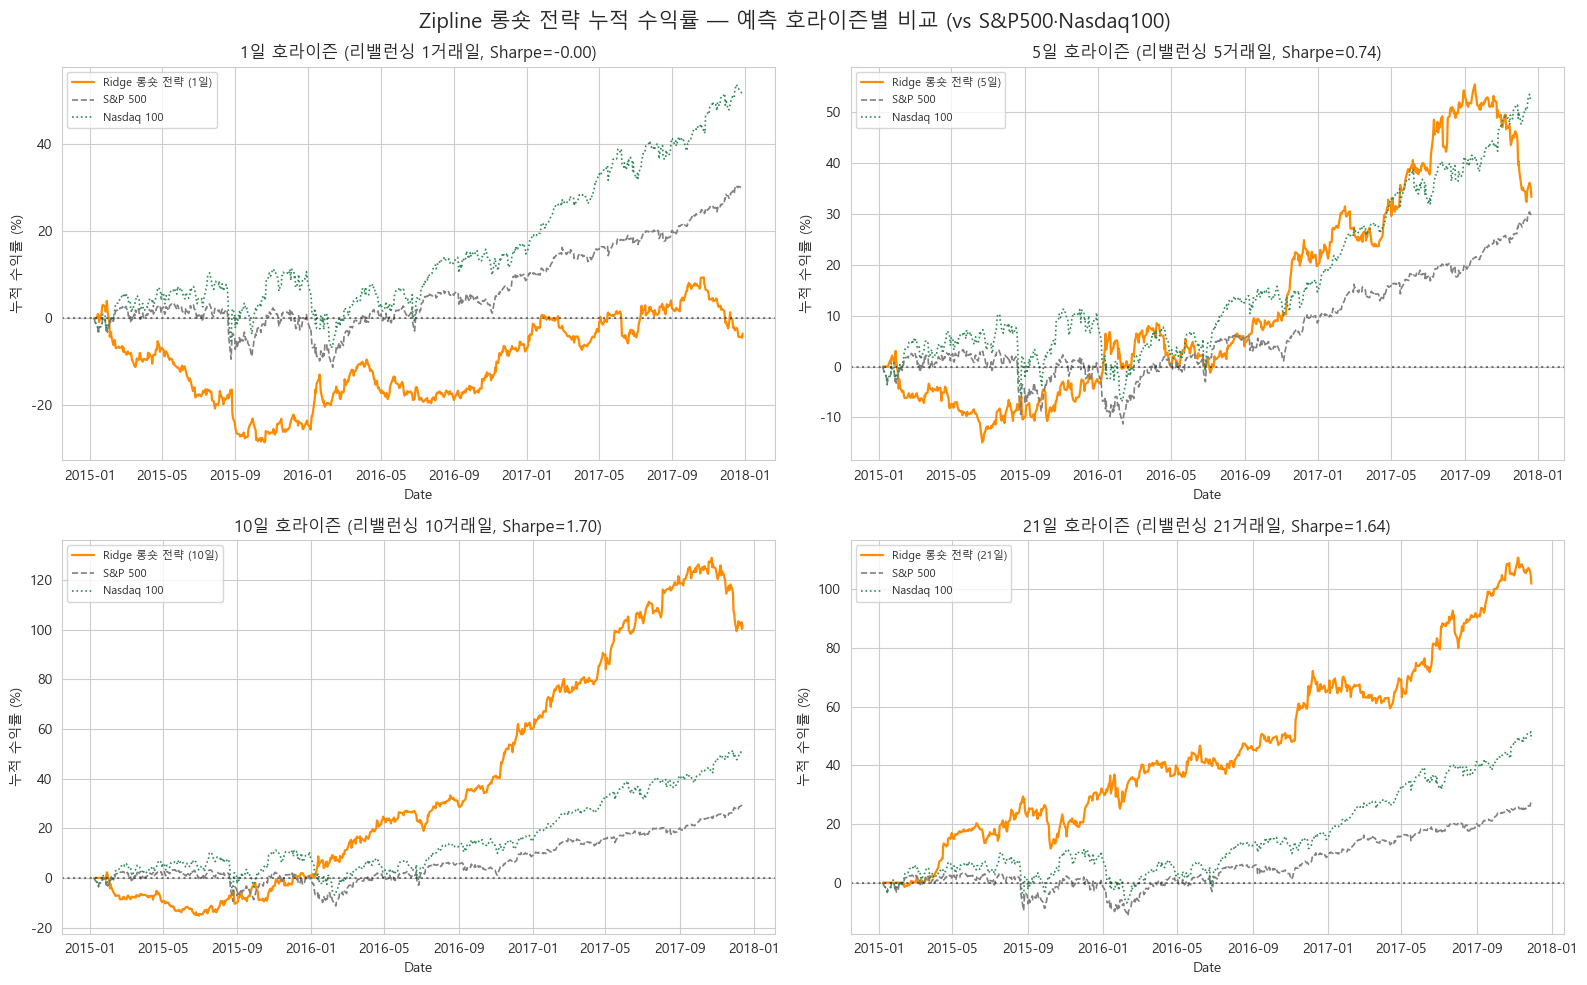

In [12]:
# Zipline 백테스트 결과 시각화 — 4개 호라이즌을 하나의 그림(2x2)으로 출력 (vs S&P500·Nasdaq100)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, h in zip(axes.flat, HORIZONS):
    perf_h = zp_results_by_horizon[h]
    r = perf_h['returns']
    sharpe_h = np.sqrt(252) * r.mean() / r.std()
    cum = (1 + r).cumprod() - 1

    # Zipline 인덱스는 tz-aware(UTC)이므로 벤치마크(tz-naive)와 맞춰 정규화 후 정렬
    idx_naive = (cum.index.tz_convert(None) if cum.index.tz is not None else cum.index).normalize()
    cum_vals = pd.Series(cum.values, index=idx_naive)
    sp_cum = _benchmark_cum_pct(_sp500_full, idx_naive)
    nd_cum = _benchmark_cum_pct(_ndx_full, idx_naive)

    ax.plot(cum_vals.index, cum_vals.values * 100, color='darkorange', lw=1.6, label=f'Ridge 롱숏 전략 ({h}일)')
    ax.plot(sp_cum.index, sp_cum.values, color='gray', lw=1.2, linestyle='--', label='S&P 500')
    ax.plot(nd_cum.index, nd_cum.values, color='seagreen', lw=1.2, linestyle=':', label='Nasdaq 100')
    ax.axhline(0, color='black', linestyle=':', alpha=0.5)
    ax.set_title(f'{h}일 호라이즌 (리밸런싱 {h}거래일, Sharpe={sharpe_h:.2f})')
    ax.set_ylabel('누적 수익률 (%)')
    ax.set_xlabel('Date')
    ax.legend(loc='upper left', fontsize=8)

plt.suptitle('Zipline 롱숏 전략 누적 수익률 — 예측 호라이즌별 비교 (vs S&P500·Nasdaq100)', fontsize=15)
plt.tight_layout()

zp_multi_plot_path = OUTPUT_DIR / 'zipline_multi_horizon_plot.png'
fig.savefig(zp_multi_plot_path, dpi=300)
print(f"Zipline 호라이즌별 결과 그래프 저장 위치: {zp_multi_plot_path.resolve()}")
plt.show()

[Cell 10] 백테스트 성과 종합 비교 (Backtrader vs Zipline × 4개 호라이즌)

In [13]:
# 두 엔진 x 4개 호라이즌 성과를 하나의 표로 종합
rows = []
for h in HORIZONS:
    btr = bt_results_by_horizon[h]
    zpr = zp_results_by_horizon[h]
    zret = zpr['returns']
    zsharpe = np.sqrt(252) * zret.mean() / zret.std()
    zcum = (1 + zret).cumprod()
    zmdd = (zcum / zcum.cummax() - 1).min() * 100

    rows.append({
        '호라이즌': f'{h}일',
        'BT_총수익률(%)': (btr['end_value'] / btr['start_value'] - 1) * 100,
        'BT_Sharpe': btr['sharpe'],
        'BT_MDD(%)': btr['maxdd'],
        'ZP_총수익률(%)': (zpr['portfolio_value'].iloc[-1] / INITIAL_CASH - 1) * 100,
        'ZP_Sharpe': zsharpe,
        'ZP_MDD(%)': zmdd,
    })

comparison_summary_df = pd.DataFrame(rows).set_index('호라이즌').round(2)
comparison_csv_path = OUTPUT_DIR / 'backtest_comparison_summary.csv'
comparison_summary_df.to_csv(comparison_csv_path)

print(f"성과 비교표 저장 위치: {comparison_csv_path.resolve()}")
display(comparison_summary_df)

성과 비교표 저장 위치: G:\내 드라이브\03.졸업논문\ml4t_pipeline\model\7단원\backtest_comparison_summary.csv


,BT_총수익률(%),BT_Sharpe,BT_MDD(%),ZP_총수익률(%),ZP_Sharpe,ZP_MDD(%)
호라이즌,,,,,,
1일,-11.23,-0.20,17.53,-3.57,-0.00,-31.22
5일,60.82,1.16,12.88,33.37,0.74,-17.48
10일,291.85,3.23,8.02,101.78,1.70,-17.16
21일,117.85,1.70,12.25,101.94,1.64,-13.74


[Cell 11] 모델 해석 — 결정 경계(분류 경계선) 시각화 및 회귀 요약(Summary)

릿지 회귀는 분류기가 아니므로 전통적인 의미의 "분류 경계선"은 없지만, 예측 수익률의 부호(상승/하락)를 기준으로 롱/숏이 갈리는 지점을 **선형 결정 경계**로 시각화할 수 있습니다. 각 호라이즌의 **가장 최근 윈도우에서 학습된 최종 모델**을 기준으로:

- 계수(절댓값) 기준 상위 2개의 **연속형** 변수만 후보로 사용합니다(원-핫 인코딩된 연도/월/섹터 더미 변수는 값이 0/1뿐이라 산점도가 퇴화되므로 제외).
- 나머지 변수는 모두 평균(표준화 기준 0)으로 고정한 상태에서, `예측값 = 0`이 되는 직선을 결정 경계로 그립니다.
- 점의 색은 실제 관측된 미래 수익률의 부호(파랑=상승, 빨강=하락)를 나타냅니다.

이어서 각 호라이즌 최종 모델의 회귀 요약(계수, 표준오차, t값, p값, R² 등)을 `statsmodels`의 OLS summary로 출력합니다(sklearn Ridge에는 `.summary()`가 없어 동일한 표준화 입력으로 통계적 해석용 OLS를 별도로 적합합니다).

결정 경계 그래프 저장 위치: G:\내 드라이브\03.졸업논문\ml4t_pipeline\model\7단원\model_decision_boundary_plot.png


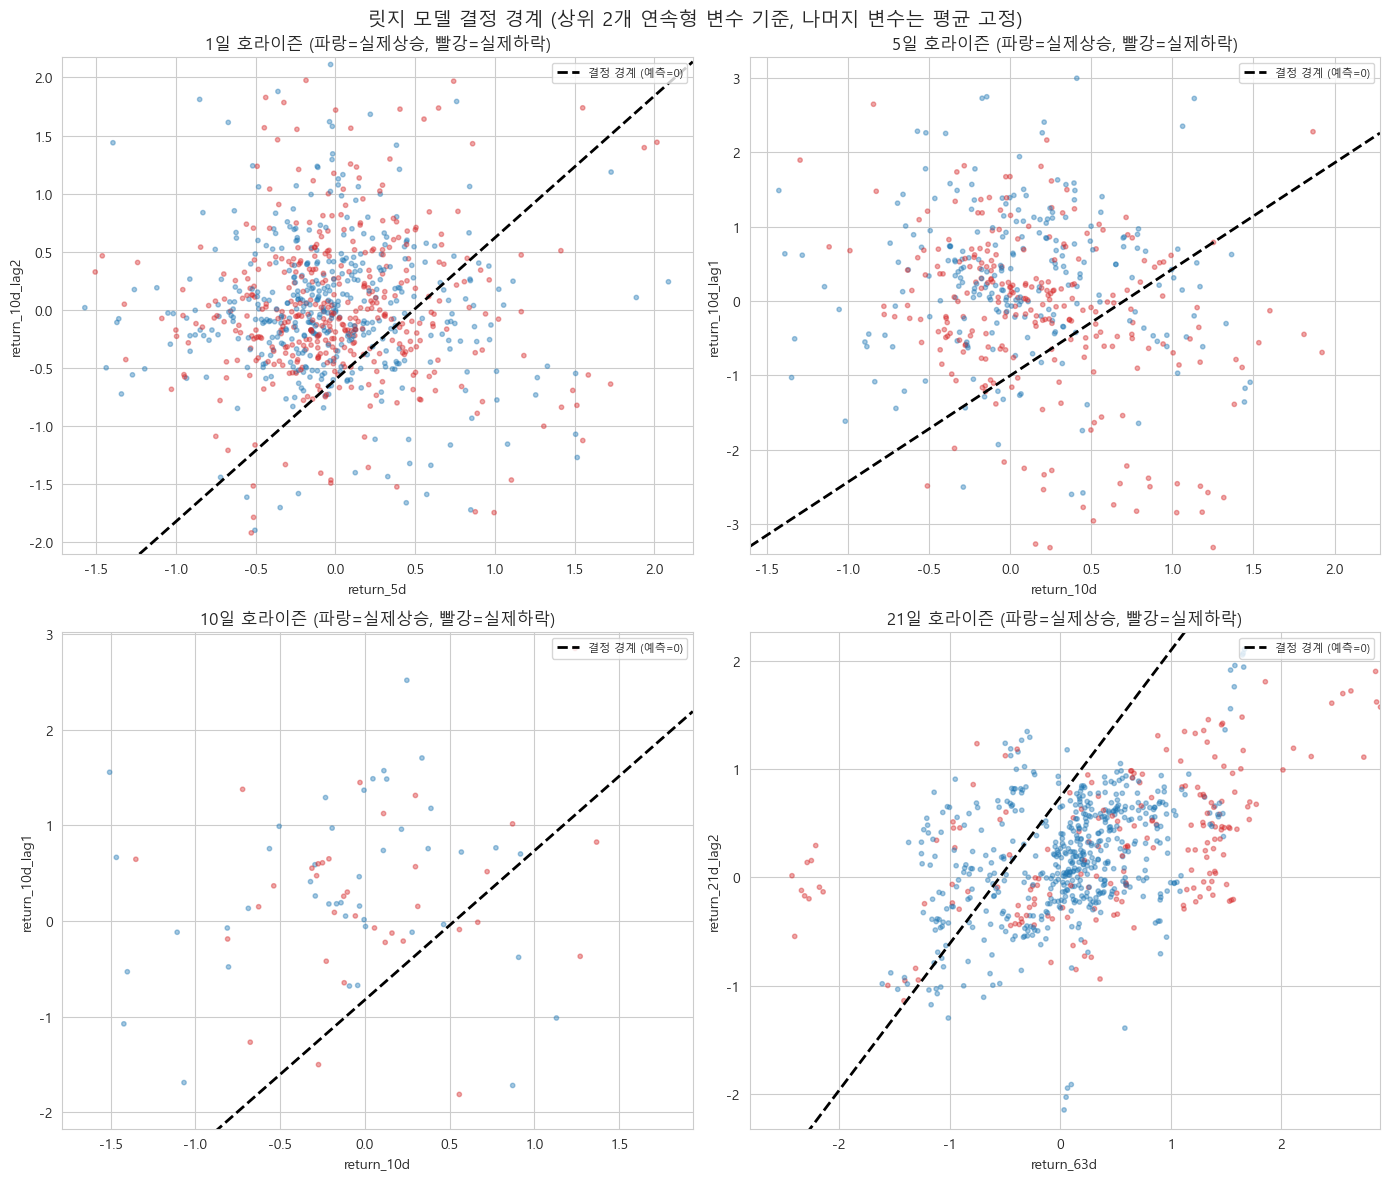

In [14]:
# 결정 경계(분류 경계선) 시각화 — 4개 호라이즌을 하나의 그림(2x2)으로 출력
# 원-핫 더미(0/1) 변수는 산점도가 퇴화되므로 연속형 변수(모멘텀 + 기술지표)만 후보로 사용
continuous_candidates = price_features + ta_features

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, h in zip(axes.flat, HORIZONS):
    info = last_split_info_by_horizon[h]
    model_h = info['model']
    features_h = info['valid_features']
    coefs = pd.Series(model_h.coef_, index=features_h)

    candidates = [f for f in continuous_candidates if f in features_h]
    top2 = coefs[candidates].abs().sort_values(ascending=False).index[:2].tolist()
    f1, f2 = top2
    i1, i2 = features_h.index(f1), features_h.index(f2)

    Xtest = info['X_test_scaled']
    y_actual = info['test_data'][info['target_col']].values

    x_min, x_max = np.percentile(Xtest[:, i1], [1, 99])
    y_min, y_max = np.percentile(Xtest[:, i2], [1, 99])
    pad_x = (x_max - x_min) * 0.1 or 0.5
    pad_y = (y_max - y_min) * 0.1 or 0.5
    x_min, x_max = x_min - pad_x, x_max + pad_x
    y_min, y_max = y_min - pad_y, y_max + pad_y

    xx = np.linspace(x_min, x_max, 200)
    c1, c2, b0 = coefs[f1], coefs[f2], model_h.intercept_
    yy_boundary = -(c1 * xx + b0) / c2

    colors = np.where(y_actual > 0, 'tab:blue', 'tab:red')
    ax.scatter(Xtest[:, i1], Xtest[:, i2], c=colors, s=10, alpha=0.4)
    ax.plot(xx, yy_boundary, color='black', lw=2, linestyle='--', label='결정 경계 (예측=0)')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel(f1)
    ax.set_ylabel(f2)
    ax.set_title(f'{h}일 호라이즌 (파랑=실제상승, 빨강=실제하락)')
    ax.legend(loc='upper right', fontsize=8)

plt.suptitle('릿지 모델 결정 경계 (상위 2개 연속형 변수 기준, 나머지 변수는 평균 고정)', fontsize=14)
plt.tight_layout()

boundary_plot_path = OUTPUT_DIR / 'model_decision_boundary_plot.png'
fig.savefig(boundary_plot_path, dpi=300)
print(f"결정 경계 그래프 저장 위치: {boundary_plot_path.resolve()}")
plt.show()

In [15]:
# 회귀 요약(Summary) — 각 호라이즌 최종 모델과 동일한 표준화 입력으로 statsmodels OLS 적합
# (sklearn Ridge는 summary()를 제공하지 않으므로, 계수·t값·p값·R² 등 해석용 통계표를 별도 생성)
import statsmodels.api as sm

for h in HORIZONS:
    info = last_split_info_by_horizon[h]
    X_df = pd.DataFrame(info['X_train_scaled'], columns=info['valid_features'])
    X_sm = sm.add_constant(X_df)
    ols_model = sm.OLS(info['y_train'].values, X_sm).fit()

    print(f"\n{'=' * 90}")
    print(f"[{h}일 호라이즌] 최종 윈도우(가장 최근 학습 구간) 회귀 요약 (statsmodels OLS)")
    print(f"{'=' * 90}")
    print(ols_model.summary())


[1일 호라이즌] 최종 윈도우(가장 최근 학습 구간) 회귀 요약 (statsmodels OLS)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.167
Date:                Fri, 11 Sep 2026   Prob (F-statistic):              0.209
Time:                        09:37:30   Log-Likelihood:                 14812.
No. Observations:                5471   AIC:                        -2.953e+04
Df Residuals:                    5426   BIC:                        -2.924e+04
Df Model:                          44                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------